<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/project1indeeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
X=df.drop(['Exited'],axis=1)

In [ ]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
X.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
X=pd.get_dummies(X,columns=['Geography','Gender'],drop_first=True)
#we can show the deleted categories like france with 0 germany 0 spain similarly 0 male 1 female

In [ ]:
from sklearn.model_selection import train_test_split
Y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train=pd.DataFrame(X_train,columns=X.columns)

In [ ]:
X_test=pd.DataFrame(X_test,columns=X.columns)

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [38]:

model=Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(3,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [39]:
model.summary() #40- 36 FROM 3*11 IMPUTS +3 BIASES AND 4 FROM 1*3+1 BIASES

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [41]:
 history=model.fit(X_train,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7934 - loss: 0.5928 - val_accuracy: 0.7987 - val_loss: 0.5197
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.5077 - val_accuracy: 0.7987 - val_loss: 0.4733
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4818 - val_accuracy: 0.7987 - val_loss: 0.4581
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4681 - val_accuracy: 0.7987 - val_loss: 0.4481
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4588 - val_accuracy: 0.7987 - val_loss: 0.4410
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4517 - val_accuracy: 0.7987 - val_loss: 0.4364
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4464 - val_accuracy: 0.7987 - val_loss: 0.4321
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4418 - val_accu

In [28]:
model.layers[0].get_weights()# last array biases #1 array weights calculated

[array([[ 3.0303437e-02, -1.1341312e-02, -3.0426683e-02],
        [-1.1254082e+00, -2.0203288e-01, -1.3465548e-01],
        [-3.2461215e-02, -1.5514719e-02, -5.8407933e-02],
        [-1.4670065e-01, -3.7398165e-01,  3.1656709e-01],
        [ 2.4559592e-01, -1.4355559e+00,  1.4483783e+00],
        [-4.0864456e-02, -1.6757175e-02, -3.5660975e-02],
        [-5.4480284e-01, -7.9937041e-01, -4.4771764e-01],
        [-1.0052955e-02,  4.5861322e-03,  7.4508693e-04],
        [ 3.1248612e-02,  3.6551625e-01, -7.9284959e-02],
        [-1.3510542e-01, -9.2168704e-02, -3.8117026e-03],
        [ 1.2845565e-01, -1.5531882e-02, -9.4653055e-02]], dtype=float32),
 array([ 1.550419  ,  0.45043492, -0.4773121 ], dtype=float32)]

In [30]:
model.layers[1].get_weights()

[array([[-1.4947835],
        [ 1.5198687],
        [ 2.1677995]], dtype=float32),
 array([-1.6775804], dtype=float32)]

In [32]:
y_log=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [34]:
y_pred=np.where(y_log>0.5,1,0)

In [36]:
from sklearn.metrics import accuracy_score

In [42]:
accuracy_score(y_test,y_pred)

0.865

In [43]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0.5, 0, 'epoch')

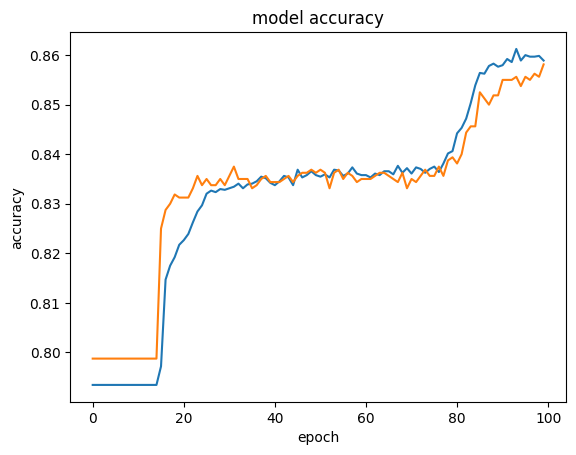

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

In [48]:
import plotly.graph_objects as go

epochs = range(1, len(history.history['accuracy']) + 1)

fig = go.Figure()

fig.add_trace(go.Scatter(x=list(epochs), y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig.add_trace(go.Scatter(x=list(epochs), y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))

fig.update_layout(
    title='Model Accuracy Over Epochs',
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    hovermode='x unified'
)

fig.show()

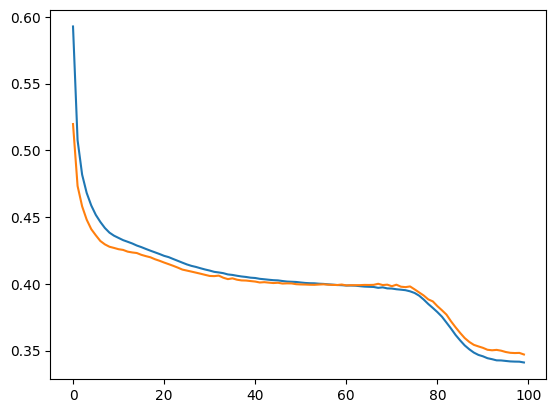

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
